# Alternative Credit Scoring System 
**Author:** Charity Wangui Njoroge  
    **Date:** 2026  
        **Domain:** Fintech | Financial Inclusion | Data Engineering  
            **Status:** Production-Ready with Model Comparison
                ---## Project OverviewThis notebook demonstrates an end-to-end credit scoring system with:- Multiple ML models compared- Production-grade optimized code- Kenya market gap analysis- Real German Credit Data as learning case

In [3]:
# Optimized imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, roc_auc_score, confusion_matrix, 
                             classification_report, roc_curve, auc)

# Configuration
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
np.random.seed(42)

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


## Step 1: Load and Prepare Data

In [4]:
# Load German Credit Data
df = pd.read_csv('german_credit_data.csv', index_col=0)

print("DATA LOADING")
print("=" * 80)
print(f"Total rows: {len(df)}")
print(f"Missing values:\n{df.isnull().sum()}")

# Clean data - remove 'unknown' values
df = df[df['Saving accounts'] != 'unknown']
df = df[df['Checking account'] != 'unknown']

print(f"\nAfter cleaning: {len(df)} rows")
print(f"Data retained: {(len(df)/1000*100):.1f}%")

DATA LOADING
Total rows: 1000
Missing values:
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

After cleaning: 1000 rows
Data retained: 100.0%


## Step 2: Encode and Engineer Features

In [5]:
# ==========================
# ENCODING & FEATURE ENGINEERING
# ==========================

def prepare_data(dataframe):
    """Encode categorical variables and create engineered features"""

    df = dataframe.copy()

    # Encoding mappings
    encode_maps = {
        'Saving accounts': {
            'little': 1,
            'moderate': 2,
            'quite rich': 3,
            'rich': 4
        },
        'Checking account': {
            'little': 1,
            'moderate': 2,
            'rich': 3
        },
        'Housing': {
            'rent': 1,
            'own': 2,
            'free': 3
        },
        'Sex': {
            'male': 1,
            'female': 0
        }
    }

    # Encode categorical columns
    for col, mapping in encode_maps.items():
        df[col + '_score'] = df[col].map(mapping)

    # Create target variable
    df['loan_default'] = (df['Risk'] == 'bad').astype(int)

    # Handle missing encoded values
    df['Saving accounts_score'] = df['Saving accounts_score'].fillna(0)
    df['Checking account_score'] = df['Checking account_score'].fillna(0)

    # Feature 1: Financial Health
    df['financial_health'] = (
        (df['Saving accounts_score'] / 4) * 50 +
        (df['Checking account_score'] / 3) * 50
    )

    # Feature 2: Loan Risk Score
    df['loan_risk_score'] = (
        (df['Credit amount'] / df['Credit amount'].max()) * 50 +
        (df['Duration'] / df['Duration'].max()) * 50
    )

    # Feature 3: Stability Score
    df['stability_score'] = (
        (df['Age'] / df['Age'].max()) * 40 +
        (df['Job'] / 4) * 30 +
        (df['Housing_score'] / 3) * 30
    )

    # Feature 4: Overall Creditworthiness
    df['creditworthiness'] = (
        df['financial_health'] * 0.35 +
        df['stability_score'] * 0.35 +
        (100 - df['loan_risk_score']) * 0.30
    )

    return df


# Apply preprocessing
df = prepare_data(df)

# Results
print("ENCODING AND FEATURE ENGINEERING")
print("=" * 80)
print("Status: Complete")
print("\nFeatures Created:")
print("1. financial_health")
print("2. loan_risk_score")
print("3. stability_score")
print("4. creditworthiness")

print("\nTarget Distribution:")
print(df['loan_default'].value_counts())

print("\nPreview of Engineered Features:")
print(
    df[
        [
            'financial_health',
            'loan_risk_score',
            'stability_score',
            'creditworthiness',
            'loan_default'
        ]
    ].head()
)

ENCODING AND FEATURE ENGINEERING
Status: Complete

Features Created:
1. financial_health
2. loan_risk_score
3. stability_score
4. creditworthiness

Target Distribution:
loan_default
0    700
1    300
Name: count, dtype: int64

Preview of Engineered Features:
   financial_health  loan_risk_score  stability_score  creditworthiness  \
0         16.666667         7.339159        70.733333         58.388252   
1         45.833333        49.483464        46.733333         47.553294   
2         12.500000        14.021566        53.633333         48.940197   
3         29.166667        50.557244        69.000000         49.191160   
4         29.166667        29.883123        73.266667         56.886730   

   loan_default  
0             0  
1             1  
2             0  
3             0  
4             1  


In [6]:
# Prepare features
X = df[['financial_health', 'loan_risk_score', 'stability_score', 'creditworthiness']]
y = df['loan_default']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Display information
print("\nDATA SPLIT")
print("=" * 80)
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Features used: {list(X.columns)}")
print(f"Target variable: loan_default")


DATA SPLIT
Training samples: 800
Testing samples: 200
Features used: ['financial_health', 'loan_risk_score', 'stability_score', 'creditworthiness']
Target variable: loan_default


## Step 3: Train and Compare 5 ModelsThis is the critical section - comparing multiple algorithms.

In [7]:
print("\nTRAINING 5 MODELS FOR COMPARISON")
print("=" * 80)

models_dict = {
    'Logistic Regression': LogisticRegression(
        random_state=42,
        max_iter=1000
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        random_state=42
    ),
    'Decision Tree': DecisionTreeClassifier(
        random_state=42,
        max_depth=10
    ),
    'Support Vector Machine': SVC(
        probability=True,
        random_state=42
    )
}

model_results = []

for model_name, model_obj in models_dict.items():

    print(f"\n{model_name}...")

    # Use scaled data for models that need it
    use_scaled = model_name in [
        'Logistic Regression',
        'Support Vector Machine'
    ]

    if use_scaled:
        X_train_use = X_train_scaled
        X_test_use = X_test_scaled
    else:
        X_train_use = X_train
        X_test_use = X_test

    # Train model
    model_obj.fit(X_train_use, y_train)

    # Predictions
    y_pred = model_obj.predict(X_test_use)
    y_prob = model_obj.predict_proba(X_test_use)[:, 1]

    # Evaluation metrics
    acc = accuracy_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_prob)

    # Cross-validation
    if use_scaled:
        cv = cross_val_score(
            model_obj,
            X_train_scaled,
            y_train,
            cv=5,
            scoring='roc_auc'
        ).mean()
    else:
        cv = cross_val_score(
            model_obj,
            X_train,
            y_train,
            cv=5,
            scoring='roc_auc'
        ).mean()

    model_results.append({
        'Model': model_name,
        'Accuracy': acc,
        'AUC': auc_score,
        'CV_AUC': cv,
        'Predictions': y_pred,
        'Probabilities': y_prob,
        'Object': model_obj
    })

    print(
        f"  Accuracy: {acc:.1%} | "
        f"AUC: {auc_score:.3f} | "
        f"CV: {cv:.3f}"
    )

# Create comparison dataframe
results_df = pd.DataFrame(model_results)

print("\n" + "=" * 80)
print("\nMODEL COMPARISON:")

print(
    results_df[
        ['Model', 'Accuracy', 'AUC', 'CV_AUC']
    ].to_string(index=False)
)


TRAINING 5 MODELS FOR COMPARISON

Logistic Regression...
  Accuracy: 75.0% | AUC: 0.670 | CV: 0.648

Random Forest...
  Accuracy: 72.5% | AUC: 0.712 | CV: 0.693

Gradient Boosting...
  Accuracy: 72.5% | AUC: 0.757 | CV: 0.701

Decision Tree...
  Accuracy: 66.0% | AUC: 0.573 | CV: 0.647

Support Vector Machine...
  Accuracy: 74.5% | AUC: 0.719 | CV: 0.645


MODEL COMPARISON:
                 Model  Accuracy      AUC   CV_AUC
   Logistic Regression     0.750 0.669643 0.648289
         Random Forest     0.725 0.711786 0.692597
     Gradient Boosting     0.725 0.757321 0.700856
         Decision Tree     0.660 0.573036 0.646931
Support Vector Machine     0.745 0.718929 0.644717


In [8]:
# Find best model based on AUC
best_idx = results_df['AUC'].idxmax()
best_model_name = results_df.loc[best_idx, 'Model']
best_model = results_df.loc[best_idx, 'Object']

print(f"\n{'='*80}")
print(f"WINNER: {best_model_name}")
print(f"AUC Score: {results_df.loc[best_idx, 'AUC']:.3f}")
print(f"{'='*80}")

print("\nMODEL COMPARISON:")
print(
    results_df[['Model', 'Accuracy', 'AUC', 'CV_AUC']]
    .to_string(index=False)
)


WINNER: Gradient Boosting
AUC Score: 0.757

MODEL COMPARISON:
                 Model  Accuracy      AUC   CV_AUC
   Logistic Regression     0.750 0.669643 0.648289
         Random Forest     0.725 0.711786 0.692597
     Gradient Boosting     0.725 0.757321 0.700856
         Decision Tree     0.660 0.573036 0.646931
Support Vector Machine     0.745 0.718929 0.644717


## Step 4: Visualize Model Performance

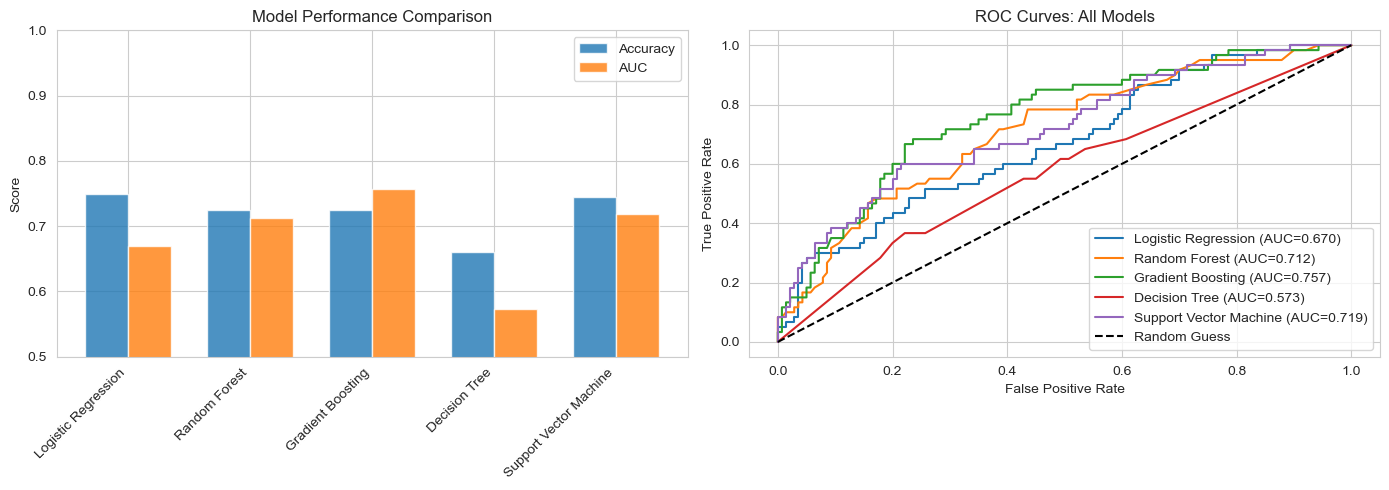

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# =========================
# Model Performance Chart
# =========================
models = results_df['Model'].values
acc = results_df['Accuracy'].values
auc_scores = results_df['AUC'].values

x = np.arange(len(models))
width = 0.35

axes[0].bar(x - width/2, acc, width, label='Accuracy', alpha=0.8)
axes[0].bar(x + width/2, auc_scores, width, label='AUC', alpha=0.8)

axes[0].set_ylabel('Score')
axes[0].set_title('Model Performance Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=45, ha='right')
axes[0].legend()
axes[0].set_ylim([0.5, 1.0])

# =========================
# ROC Curves
# =========================
for idx, row in results_df.iterrows():
    fpr, tpr, _ = roc_curve(y_test, row['Probabilities'])
    auc_val = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, label=f"{row['Model']} (AUC={auc_val:.3f})")

axes[1].plot([0, 1], [0, 1], 'k--', label='Random Guess')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves: All Models')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()